In [6]:
%matplotlib inline
%load_ext autoreload
from verimon.analysis import *

experiment_dir = "../stats/exp-2025-01-20_15-19-13-verify"
experiment_data = load_experiment_data(experiment_dir)

symbols, colors = add_symbol_color(experiment_data, verify=True)

clean_data(experiment_data)

for data in experiment_data:
    if "error" in data["result"]:
        data["result"]["time"] = 0
        data["result"]["product_time"] = 0
        data["result"]["paynt_time"] = 0
        data["result"]["pomdp_states"] = 0

add_short_names(experiment_data, verify=True)

experiments_in_legends = False
save_figures = True
save_path = "../VerifiableMonitorsTex/inprogress/images/plots"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loaded 276 JSON files from ../stats/exp-2025-01-20_15-19-13-verify


In [7]:
import os

os.system(f"grep -r 'WARNING' {experiment_dir}/logs/*")
os.system(f"grep -r 'ERROR' {experiment_dir}/logs/*")
longest_experiment = max(experiment_data, key=lambda x: x["time"]["total"])
print(
    f"Longest experiment {longest_experiment['experiment']['learn_experiment']['name']} {longest_experiment['experiment']['variant']} took {longest_experiment['time']['total']:.2f}s ({longest_experiment['time']['total'] / 60:.2f} min ({longest_experiment['time']['total'] / (60 * 60):.2f} h))."
)

../stats/exp-2025-01-20_15-19-13-verify/logs/2025-01-20_15-19-13_runtime-tover_(results_file=2025-01-17_16-28-57_snakes_ladders_(horizon=12,slack=[0, 0]).json,intermediate_monitor=0.0,search=fn,threshold=0.3).log:ERROR:2025-01-20 15:34:30,518 - (0.00s) - experiment.py:672 - Error in verification: Traceback (most recent call last):
../stats/exp-2025-01-20_15-19-13-verify/logs/2025-01-20_15-19-13_runtime-tover_(results_file=2025-01-17_16-28-57_snakes_ladders_(horizon=12,slack=[0, 0]).json,intermediate_monitor=0.0,search=fn,threshold=None).log:ERROR:2025-01-20 15:34:30,326 - (0.16s) - experiment.py:672 - Error in verification: Traceback (most recent call last):
../stats/exp-2025-01-20_15-19-13-verify/logs/2025-01-20_15-19-13_runtime-tover_(results_file=2025-01-17_16-28-57_snakes_ladders_(horizon=12,slack=[0, 0]).json,intermediate_monitor=0.0,search=fp,threshold=0.3).log:ERROR:2025-01-20 15:34:30,722 - (0.00s) - experiment.py:672 - Error in verification: Traceback (most recent call last):


In [8]:
import matplotlib.backend_bases
from matplotlib.backends.backend_pgf import FigureCanvasPgf

matplotlib.backend_bases.register_backend("pdf", FigureCanvasPgf)

import matplotlib.lines as mlines
import matplotlib.pyplot as plt

# Create a legend for the symbols and colors
# legend_elements = [
#     mlines.Line2D(
#         [],
#         [],
#         linewidth=0,
#         color=data["color"],
#         marker=data["symbol"],
#         label=f'({data["experiment"]["short_name"]}) {data["experiment"]["name"]} {data["experiment"]["variant"]}',
#     )
#     for data in experiment_data
# ]

# plt.legend(handles=legend_elements, loc="center", ncol=2)
# plt.axis("off")
# if save_figures:
#     plt.savefig(f"{save_path}/legend.pgf", bbox_inches="tight")
# plt.show()

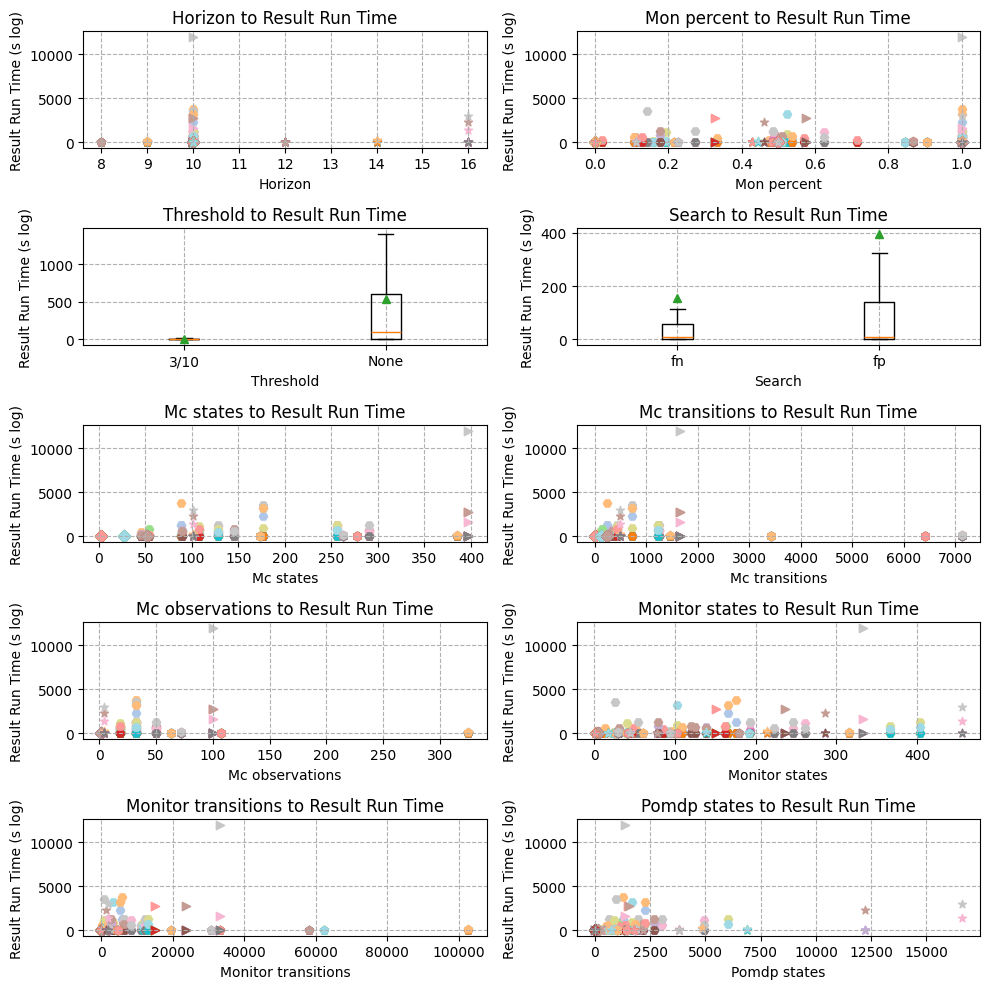

In [ ]:
parameters = [
    ("experiment", "horizon", "log"),
    ("experiment", "mon_percent", "log"),
    ("experiment", "threshold", "box"),
    ("experiment", "search", "box"),
    ("mc", "mc_states", "log"),
    ("mc", "mc_transitions", "log"),
    ("mc", "mc_observations", "log"),
    ("monitor", "monitor_states", "log"),
    ("monitor", "monitor_transitions", "log"),
    ("result", "pomdp_states", "log"),
]

runtime_by_params(
    [data for data in experiment_data],
    "result",
    parameters,
    experiments_in_legends=experiments_in_legends,
)

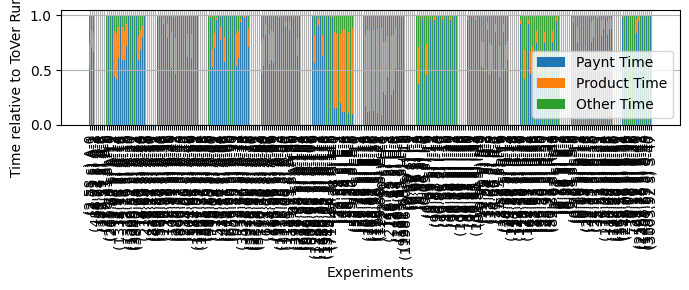

In [10]:
import numpy as np

product_times = [
    (
        data["result"]["product_time"] / data["result"]["time"]
        if "result" in data and data["result"]["time"] != 0
        else 0
    )
    for data in experiment_data
]
paynt_times = [
    (
        data["result"]["paynt_time"] / data["result"]["time"]
        if "result" in data and data["result"]["time"] != 0
        else 0
    )
    for data in experiment_data
]
# double_check_times = [
#     (
#         data["result"]["double_check_time"] / data["result"]["time"]
#         if "result" in data and data["result"]["time"] != 0 and data["result"]["double_check_time"] is not None
#         else 0
#     )
#     for data in experiment_data
# ]
other_times = [
    (
        1
        - (
            data["result"]["product_time"]
            + data["result"]["paynt_time"]
            # + (
            #     data["result"]["double_check_time"]
            #     if data["result"]["double_check_time"] is not None
            #     else 0
            # )
        )
        / data["result"]["time"]
        if "result" in data and data["result"]["time"] != 0
        else 1
    )
    for data in experiment_data
]

if experiments_in_legends:
    experiment_names = [
        f"{data['experiment']['name']}\n{data['experiment']['variant']}\n({data['time']['total']/(60*60):.2f} h)"
        for data in experiment_data
    ]
else:
    experiment_names = [
        f"({data['time']['total']:.2f} s) {data['experiment']['short_name']}"
        for data in experiment_data
    ]

plt.figure(figsize=(7, 3))
index = range(len(experiment_data))
bottom = np.zeros(len(experiment_data))


plt.bar(index, paynt_times, label="Paynt Time")
bottom += paynt_times
plt.bar(index, product_times, bottom=bottom, label="Product Time")
bottom += product_times
# plt.bar(
#     index,
#     double_check_times,
#     bottom=bottom,
#     label="Double check Time",
# )
# bottom += double_check_times
plt.bar(
    index,
    other_times,
    bottom=bottom,
    label="Other Time",
)

plt.xlabel("Experiments")
plt.ylabel("Time relative to ToVer Run Time")
plt.xticks(index, experiment_names, rotation=90)
plt.legend()

plt.tight_layout()
plt.grid()
if save_figures:
    plt.savefig(f"{save_path}/Tover_relative.pgf", bbox_inches="tight")
plt.show()